In [2]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np

In [3]:
import pandas as pd
data=pd.read_csv('wine.csv')
y=data['quality']
X=data.drop(['quality'],axis=1)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.25,
                                               random_state=42)


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(32,input_shape = (11,),activation = 'relu'))
model.add(Dense(6,activation='softmax'))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
y_train = y_train - 3
y_test = y_test - 3
print(np.unique(y_train))

[0 1 2 3 4 5]


d:\Coding_here\PythonLearningsOnly\InternshipProgram3rdYear\PythonProgram\env313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.fit(X_train,
          y_train,
          epochs=100,
          batch_size=32,
          validation_data=(X_test,y_test))

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3570 - loss: 1.6154 - val_accuracy: 0.4525 - val_loss: 1.4645
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4712 - loss: 1.3892 - val_accuracy: 0.4850 - val_loss: 1.3019
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5154 - loss: 1.2506 - val_accuracy: 0.5225 - val_loss: 1.1995
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5446 - loss: 1.1595 - val_accuracy: 0.5300 - val_loss: 1.1320
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5605 - loss: 1.0991 - val_accuracy: 0.5525 - val_loss: 1.0873
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5863 - loss: 1.0608 - val_accuracy: 0.5600 - val_loss: 1.0574
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5947 - loss: 1.0342 - val_accuracy: 0.5625 - val_loss: 1.0382
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6055 - loss: 1.0149 - val_accuracy: 0.5650 - 

In [8]:
model.save("wine_model.h5")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [10]:
pred = model.predict(X_test)
pred = np.argmax(pred,axis = 1)
pred = pred + 3
print(pred)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[5 5 6 5 6 5 5 5 6 6 6 5 6 5 5 7 5 6 7 5 4 5 6 6 5 6 5 5 5 6 5 5 6 5 6 5 6
 6 6 6 5 5 6 5 6 6 7 5 5 6 5 5 6 7 5 5 6 6 6 5 6 6 5 5 7 5 6 6 7 5 6 5 6 6
 6 5 7 5 6 7 5 7 5 5 6 6 5 6 6 5 6 5 5 5 5 5 5 6 5 6 5 5 6 6 6 6 6 5 7 5 6
 5 6 5 6 6 6 5 5 6 6 6 6 6 5 5 6 6 5 6 6 5 5 6 6 5 5 5 5 6 6 6 6 5 6 5 6 5
 6 5 6 7 5 6 6 6 5 6 5 6 6 6 6 5 5 6 5 5 5 5 5 5 7 6 7 6 6 5 5 5 5 7 5 7 5
 6 6 6 7 6 6 6 5 6 6 5 5 5 6 6 5 5 5 5 7 6 5 5 6 6 6 5 6 6 6 6 6 5 6 5 5 6
 6 6 5 5 5 7 5 5 5 5 6 6 6 6 5 6 6 5 5 5 6 6 5 5 6 5 6 5 5 5 6 6 3 5 5 6 6
 7 6 6 5 7 6 7 5 5 6 6 5 6 5 5 5 5 6 6 6 5 7 5 5 5 5 6 5 6 5 5 5 7 6 5 5 6
 5 6 7 6 5 5 7 5 5 5 6 6 6 7 6 6 6 6 5 6 5 5 6 5 6 6 6 5 5 5 6 5 5 6 7 7 5
 5 5 6 6 6 5 5 6 7 5 5 6 5 6 5 6 5 6 6 5 5 6 6 6 5 5 5 5 5 5 6 5 6 6 5 5 5
 5 5 6 5 5 6 5 6 6 5 5 6 7 5 6 6 6 5 5 6 5 5 5 6 6 6 7 6 5 6]


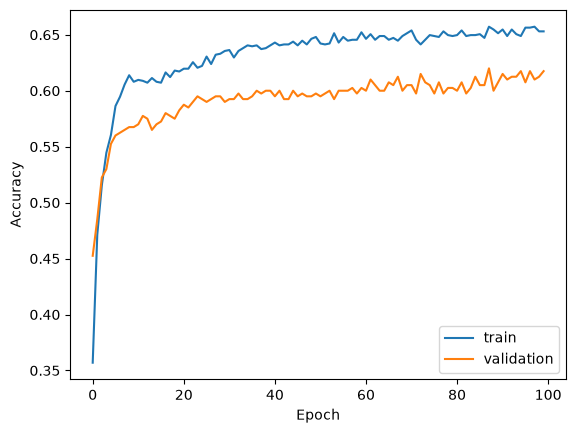

In [11]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['accuracy'],label = 'train')
plt.plot(model.history.history['val_accuracy'],label = 'validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

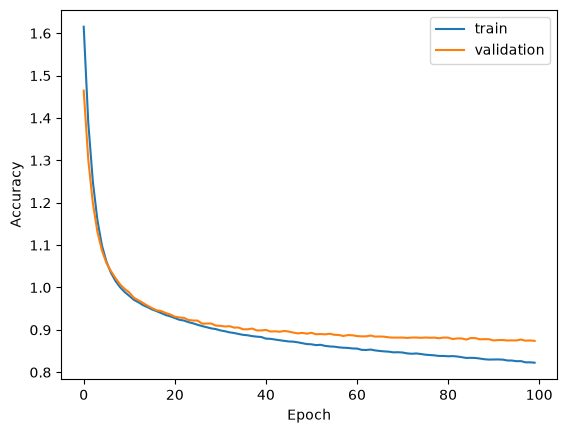

In [12]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'],label = 'train')
plt.plot(model.history.history['val_loss'],label = 'validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()